# Week 6 — Anomaly Detection on Aido Rover Telemetry

## Objective

This notebook develops and evaluates anomaly detection methods for synthetic Aido Rover telemetry.

Five controlled fault types are injected into the Week 2 telemetry dataset:

1. Motor stall
2. Battery accelerated degradation
3. GPS disruption
4. LiDAR saturation
5. IMU axis failure

Two anomaly detection approaches are benchmarked:

- Statistical threshold detection
- Isolation Forest

The methods are evaluated across fault types using AUROC, precision, and recall. Isolation Forest performance is evaluated across 10 random seeds to assess robustness.

## 1. Import Libraries

Import the libraries required for data manipulation, visualization, anomaly detection, and model evaluation.

In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score
)

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 2. Load Telemetry Dataset

Load the synthetic Aido Rover telemetry dataset generated in Week 2.

This dataset represents the baseline fleet telemetry used for the Week 6 controlled fault injection and anomaly detection experiments.

In [143]:
# Load telemetry dataset
df = pd.read_csv("../Data/aido_rover_telemetry.csv")

# Basic dataset information
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Number of rover units: {df['rover_id'].nunique()}")

# Preview
print("\nDataset Preview")
display(df.head())

# Column summary
column_summary = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Missing Count": df.isna().sum(),
    "Missing (%)": (df.isna().mean() * 100).round(2)
})

print("\nColumn Summary")
display(column_summary)

Dataset shape: 181,440 rows × 20 columns
Number of rover units: 30

Dataset Preview


,rover_id,timestamp,operational_mode,latitude,longitude,lidar_distance_m,wheel_torque_fl,wheel_torque_fr,wheel_torque_rl,wheel_torque_rr,imu_accel_x,imu_accel_y,imu_accel_z,ambient_temperature_c,battery_soc,task_success,gps_dropout_flag,lidar_saturation_flag,battery_drop_flag,sensor_noise_flag
0,AIDO_001,2026-07-01 00:00:00,PATROL,1.354202,103.821034,13.699527,15.488216,17.496137,18.483317,16.461332,0.027548,0.065830,9.635538,22.987241,76.428284,1,0,0,0,0
1,AIDO_001,2026-07-01 00:05:00,FAULT,1.354486,103.820582,0.486087,5.560991,19.340842,4.025754,12.218663,-0.209815,-0.043348,9.601425,21.239938,76.275079,1,0,0,0,0
2,AIDO_001,2026-07-01 00:10:00,ALERT,1.354647,103.820291,0.976473,35.108406,21.019085,15.790379,27.107367,-0.009860,-0.163633,9.721586,21.241867,76.155109,1,0,0,0,0
3,AIDO_001,2026-07-01 00:15:00,PATROL,1.353859,103.821427,6.150354,22.704654,16.397383,12.056365,20.362447,0.554334,-0.029707,9.735898,21.616087,76.014695,1,0,0,0,0
4,AIDO_001,2026-07-01 00:20:00,PATROL,1.354567,103.820920,12.263115,24.153797,10.759237,13.542237,20.654680,-0.063300,-0.234918,10.039323,21.213952,75.885342,1,0,0,0,0



Column Summary


,Data Type,Missing Count,Missing (%)
rover_id,object,0,0.0
timestamp,object,0,0.0
operational_mode,object,0,0.0
latitude,float64,3628,2.0
longitude,float64,3628,2.0
lidar_distance_m,float64,0,0.0
wheel_torque_fl,float64,0,0.0
wheel_torque_fr,float64,0,0.0
wheel_torque_rl,float64,0,0.0
wheel_torque_rr,float64,0,0.0


## 3. Prepare Baseline Telemetry

The original telemetry dataset contains four pre-existing anomaly types: GPS dropout, LiDAR saturation, battery sudden-drop events, and sensor noise spikes.

Before injecting controlled faults, the dataset is prepared by converting timestamps, sorting observations chronologically by rover, and identifying observations affected by any pre-existing anomaly.

A clean baseline is then defined to support controlled fault injection and anomaly detection experiments.

In [144]:
# Create a working copy
telemetry = df.copy()

# Convert timestamp to datetime
telemetry["timestamp"] = pd.to_datetime(telemetry["timestamp"])

# Sort observations by rover and timestamp
telemetry = (
    telemetry
    .sort_values(["rover_id", "timestamp"])
    .reset_index(drop=True)
)

# Existing anomaly indicators
existing_anomaly_flags = [
    "gps_dropout_flag",
    "lidar_saturation_flag",
    "battery_drop_flag",
    "sensor_noise_flag"
]

# Identify rows affected by at least one existing anomaly
telemetry["existing_anomaly_flag"] = (
    telemetry[existing_anomaly_flags]
    .max(axis=1)
)

print(f"Dataset shape: {telemetry.shape[0]:,} rows × {telemetry.shape[1]} columns")
print(
    f"Timestamp range: {telemetry['timestamp'].min()} "
    f"to {telemetry['timestamp'].max()}"
)
print(f"Number of rover units: {telemetry['rover_id'].nunique()}")

Dataset shape: 181,440 rows × 21 columns
Timestamp range: 2026-07-01 00:00:00 to 2026-07-21 23:55:00
Number of rover units: 30


### Existing Anomaly Summary

The original telemetry includes several intentionally injected anomalies. Their frequency is summarized before defining the clean baseline.

This step helps distinguish pre-existing data-quality anomalies from the controlled operational faults introduced later in the experiment.

In [145]:
anomaly_summary = pd.DataFrame({
    "Count": telemetry[existing_anomaly_flags].sum(),
    "Percentage (%)": (
        telemetry[existing_anomaly_flags].mean() * 100
    ).round(2)
})

anomaly_summary.index = [
    "GPS Dropout",
    "LiDAR Saturation",
    "Battery Sudden Drop",
    "Sensor Noise"
]

display(anomaly_summary)

rows_with_anomaly = telemetry["existing_anomaly_flag"].sum()

print(
    f"Rows with at least one existing anomaly: "
    f"{rows_with_anomaly:,} "
    f"({rows_with_anomaly / len(telemetry) * 100:.2f}%)"
)

,Count,Percentage (%)
GPS Dropout,3628,2.0
LiDAR Saturation,1814,1.0
Battery Sudden Drop,5443,3.0
Sensor Noise,9072,5.0


Rows with at least one existing anomaly: 19,256 (10.61%)


### Clean Baseline Definition

A clean baseline observation is defined as a telemetry record where none of the pre-existing anomaly indicators are active.

The original observations are not removed from the working dataset. Instead, the clean subset provides a controlled pool for fault injection and normal-data model training.

This separation reduces interference from unrelated anomalies when evaluating the detection performance of each controlled fault type.

In [146]:
clean_mask = telemetry["existing_anomaly_flag"] == 0

clean_baseline = telemetry.loc[clean_mask].copy()

baseline_summary = pd.DataFrame({
    "Rows": [
        len(telemetry),
        len(clean_baseline)
    ],
    "Percentage (%)": [
        100,
        len(clean_baseline) / len(telemetry) * 100
    ]
}, index=[
    "Full Telemetry Dataset",
    "Clean Baseline"
])

baseline_summary["Percentage (%)"] = (
    baseline_summary["Percentage (%)"].round(2)
)

display(baseline_summary)

,Rows,Percentage (%)
Full Telemetry Dataset,181440,100.00
Clean Baseline,162184,89.39


## 4. Controlled Fault Injection

Five controlled fault types are introduced into clean telemetry observations to simulate realistic sensor and operational failures:

1. **Motor Stall** — loss of torque from one wheel during operation.
2. **Battery Accelerated Degradation** — unusually rapid battery discharge over a continuous period.
3. **GPS Disruption** — sustained loss of GPS positioning data.
4. **LiDAR Saturation** — LiDAR measurements become fixed at the sensor's upper limit.
5. **IMU Axis Failure** — one acceleration axis becomes unresponsive.

Faults are injected into separate telemetry segments to create known ground-truth labels for evaluating anomaly detection performance.

### 4.1 Fault Injection Setup

Faults are injected as continuous events rather than isolated observations. This preserves the temporal structure of robot telemetry and more closely represents realistic operational failures.

Only clean baseline observations are selected for controlled fault injection to reduce overlap with pre-existing anomalies.

In [147]:
fault_data = telemetry.copy()

fault_types = [
    "motor_stall",
    "battery_degradation",
    "gps_disruption",
    "lidar_saturation",
    "imu_axis_failure"
]

for fault in fault_types:
    fault_data[f"{fault}_flag"] = 0

fault_data["controlled_fault_flag"] = 0
fault_data["fault_type"] = "normal"

print(f"Rows prepared: {len(fault_data):,}")

Rows prepared: 181,440


### 4.2 Motor Stall

A motor stall is simulated by forcing one wheel's torque close to zero for a continuous telemetry segment while the remaining wheels continue operating normally.

This creates an abnormal wheel-torque imbalance that should be detectable from the multivariate sensor stream.

In [148]:
rng = np.random.default_rng(RANDOM_SEED)

event_length = 12
n_events = 20

eligible_rovers = clean_baseline["rover_id"].unique()

wheel_columns = [
    "wheel_torque_fl",
    "wheel_torque_fr",
    "wheel_torque_rl",
    "wheel_torque_rr"
]

motor_stall_events = []
used_indices = set()

for event_id in range(1, n_events + 1):

    while True:
        rover = rng.choice(eligible_rovers)

        rover_rows = clean_baseline[
            clean_baseline["rover_id"] == rover
        ].index.to_numpy()

        start_pos = rng.integers(
            0,
            len(rover_rows) - event_length
        )

        event_idx = rover_rows[
            start_pos:start_pos + event_length
        ]

        times = telemetry.loc[event_idx, "timestamp"]

        expected_times = pd.date_range(
            start=times.iloc[0],
            periods=event_length,
            freq="5min"
        )

        is_continuous = np.array_equal(
            times.to_numpy(),
            expected_times.to_numpy()
        )

        is_unused = not any(
            idx in used_indices
            for idx in event_idx
        )

        valid_mode = (
            telemetry.loc[
                event_idx,
                "operational_mode"
            ].isin(["PATROL", "ALERT"]).all()
        )

        if (
            is_continuous
            and is_unused
            and valid_mode
        ):
            break

    stalled_wheel = rng.choice(wheel_columns)

    motor_stall_events.append({
        "event_id": event_id,
        "rover_id": rover,
        "wheel": stalled_wheel,
        "indices": event_idx
    })

    used_indices.update(event_idx)

print(
    f"Motor stall events selected: "
    f"{len(motor_stall_events)}"
)

Motor stall events selected: 20


In [149]:
fault_data["stalled_wheel"] = pd.NA

for event in motor_stall_events:

    idx = event["indices"]
    wheel = event["wheel"]

    fault_data.loc[idx, wheel] = rng.normal(
        0.1,
        0.03,
        len(idx)
    )

    fault_data.loc[idx, "motor_stall_flag"] = 1
    fault_data.loc[idx, "controlled_fault_flag"] = 1
    fault_data.loc[idx, "fault_type"] = "motor_stall"
    fault_data.loc[idx, "stalled_wheel"] = wheel

motor_stall_indices = np.concatenate([
    event["indices"]
    for event in motor_stall_events
])

print(
    f"Motor stall observations injected: "
    f"{len(motor_stall_indices):,}"
)

Motor stall observations injected: 240


### Motor Stall Validation

Motor stall events were simulated across randomly selected wheel positions, with each event lasting one hour. The affected wheel's torque was reduced close to zero while the remaining wheel channels were left unchanged.

The following results verify that the injected faults exhibit the intended duration and torque behavior.

In [150]:
motor_event_summary = pd.DataFrame([
    {
        "Event": event["event_id"],
        "Rover": event["rover_id"],
        "Stalled Wheel": event["wheel"].replace("wheel_torque_", "").upper(),
        "Start": telemetry.loc[event["indices"][0], "timestamp"],
        "End": telemetry.loc[event["indices"][-1], "timestamp"],
        "Observations": len(event["indices"])
    }
    for event in motor_stall_events
])

display(motor_event_summary)

,Event,Rover,Stalled Wheel,Start,End,Observations
0,1,AIDO_017,FL,2026-07-12 15:05:00,2026-07-12 16:00:00,12
1,2,AIDO_009,FL,2026-07-02 15:00:00,2026-07-02 15:55:00,12
2,3,AIDO_017,FR,2026-07-03 22:05:00,2026-07-03 23:00:00,12
3,4,AIDO_010,RR,2026-07-21 22:00:00,2026-07-21 22:55:00,12
4,5,AIDO_006,FR,2026-07-05 17:50:00,2026-07-05 18:45:00,12
5,6,AIDO_006,RR,2026-07-19 01:50:00,2026-07-19 02:45:00,12
6,7,AIDO_029,RR,2026-07-03 04:10:00,2026-07-03 05:05:00,12
7,8,AIDO_029,FR,2026-07-02 20:40:00,2026-07-02 21:35:00,12
8,9,AIDO_021,RL,2026-07-11 22:25:00,2026-07-11 23:20:00,12
9,10,AIDO_004,RR,2026-07-09 04:05:00,2026-07-09 05:00:00,12


In [151]:
wheel_distribution = (
    motor_event_summary["Stalled Wheel"]
    .value_counts()
    .rename_axis("Wheel")
    .reset_index(name="Events")
)

display(wheel_distribution)

,Wheel,Events
0,RR,6
1,FR,6
2,FL,6
3,RL,2


In [152]:
validation_rows = []

for event in motor_stall_events:

    idx = event["indices"]
    wheel = event["wheel"]

    validation_rows.append({
        "Event": event["event_id"],
        "Wheel": wheel.replace("wheel_torque_", "").upper(),
        "Original Mean Torque": telemetry.loc[idx, wheel].mean(),
        "Stall Mean Torque": fault_data.loc[idx, wheel].mean()
    })

motor_validation = pd.DataFrame(validation_rows)

motor_validation[
    ["Original Mean Torque", "Stall Mean Torque"]
] = motor_validation[
    ["Original Mean Torque", "Stall Mean Torque"]
].round(2)

display(motor_validation)

,Event,Wheel,Original Mean Torque,Stall Mean Torque
0,1,FL,20.25,0.11
1,2,FL,16.52,0.10
2,3,FR,17.94,0.09
3,4,RR,17.39,0.10
4,5,FR,17.77,0.10
5,6,RR,18.36,0.08
6,7,RR,19.79,0.11
7,8,FR,17.82,0.11
8,9,RL,20.17,0.09
9,10,RR,16.22,0.09


**Interpretation**

Motor stall events were distributed across all four wheel positions, with no single wheel exclusively representing the fault condition. Across all 20 events, the affected wheel torque decreased from its original operating level to approximately zero, confirming that the intended motor stall behavior was successfully simulated.

### 4.3 Battery Accelerated Degradation

Accelerated battery degradation is simulated as an unusually rapid decline in battery state of charge over a continuous telemetry period.

Rather than creating a single sudden drop, the injected fault produces a progressive decline in battery SoC, representing abnormal discharge behavior over time.

In [153]:
event_length = 24
n_events = 20
min_start_soc = 40
min_active_ratio = 0.75

candidate_events = []

for rover in eligible_rovers:

    rover_df = telemetry[
        telemetry["rover_id"] == rover
    ].copy()

    idx = rover_df.index.to_numpy()

    clean = (
        rover_df["existing_anomaly_flag"].to_numpy() == 0
    )

    no_controlled_fault = (
        fault_data.loc[
            idx,
            "controlled_fault_flag"
        ].to_numpy() == 0
    )

    active = (
        rover_df["operational_mode"]
        .isin(["PATROL", "ALERT"])
        .to_numpy()
    )

    timestamps = rover_df[
        "timestamp"
    ].to_numpy()

    soc = rover_df[
        "battery_soc"
    ].to_numpy()

    clean_window = (
        np.convolve(
            clean.astype(int),
            np.ones(event_length, dtype=int),
            mode="valid"
        )
        == event_length
    )

    fault_free_window = (
        np.convolve(
            no_controlled_fault.astype(int),
            np.ones(event_length, dtype=int),
            mode="valid"
        )
        == event_length
    )

    active_ratio = (
        np.convolve(
            active.astype(int),
            np.ones(event_length, dtype=int),
            mode="valid"
        )
        / event_length
    )

    time_steps = (
        np.diff(timestamps)
        == np.timedelta64(5, "m")
    )

    continuous_window = (
        np.convolve(
            time_steps.astype(int),
            np.ones(event_length - 1, dtype=int),
            mode="valid"
        )
        == event_length - 1
    )

    start_soc_ok = (
        soc[:len(clean_window)]
        >= min_start_soc
    )

    valid_start = (
        clean_window
        & fault_free_window
        & continuous_window
        & (active_ratio >= min_active_ratio)
        & start_soc_ok
    )

    start_positions = np.flatnonzero(
        valid_start
    )

    for start_pos in start_positions:
        event_idx = idx[
            start_pos:start_pos + event_length
        ]

        candidate_events.append({
            "rover_id": rover,
            "indices": event_idx
        })

rng.shuffle(candidate_events)

battery_degradation_events = []
battery_used_indices = set()

for candidate in candidate_events:

    event_idx = candidate["indices"]

    no_overlap = not any(
        idx in battery_used_indices
        for idx in event_idx
    )

    if no_overlap:

        battery_degradation_events.append({
            "event_id":
                len(battery_degradation_events) + 1,
            "rover_id":
                candidate["rover_id"],
            "indices":
                event_idx
        })

        battery_used_indices.update(
            event_idx
        )

    if len(
        battery_degradation_events
    ) == n_events:
        break

print(
    f"Candidate events available: "
    f"{len(candidate_events):,}"
)

print(
    f"Battery degradation events selected: "
    f"{len(battery_degradation_events)}"
)

Candidate events available: 1,980
Battery degradation events selected: 20


In [154]:
for event in battery_degradation_events:

    idx = event["indices"]

    original_soc = telemetry.loc[
        idx,
        "battery_soc"
    ].to_numpy()

    extra_decline = np.linspace(
        0,
        25,
        len(idx)
    )

    degraded_soc = np.clip(
        original_soc - extra_decline,
        0,
        100
    )

    fault_data.loc[idx, "battery_soc"] = degraded_soc
    fault_data.loc[idx, "battery_degradation_flag"] = 1
    fault_data.loc[idx, "controlled_fault_flag"] = 1
    fault_data.loc[idx, "fault_type"] = "battery_degradation"

battery_degradation_indices = np.concatenate([
    event["indices"]
    for event in battery_degradation_events
])

print(
    f"Battery degradation observations injected: "
    f"{len(battery_degradation_indices):,}"
)

Battery degradation observations injected: 480


### Battery Degradation Validation

The simulated degradation events preserve the original battery trajectory while introducing an additional progressive decline in state of charge.

Validation compares the original and modified SoC behavior to confirm that the injected events represent sustained accelerated discharge rather than isolated battery drops.

In [155]:
battery_event_summary = pd.DataFrame([
    {
        "Event": event["event_id"],
        "Rover": event["rover_id"],
        "Start": telemetry.loc[event["indices"][0], "timestamp"],
        "End": telemetry.loc[event["indices"][-1], "timestamp"],
        "Observations": len(event["indices"])
    }
    for event in battery_degradation_events
])

display(battery_event_summary)

,Event,Rover,Start,End,Observations
0,1,AIDO_019,2026-07-01 11:10:00,2026-07-01 13:05:00,24
1,2,AIDO_021,2026-07-01 19:35:00,2026-07-01 21:30:00,24
2,3,AIDO_020,2026-07-01 17:15:00,2026-07-01 19:10:00,24
3,4,AIDO_012,2026-07-02 05:45:00,2026-07-02 07:40:00,24
4,5,AIDO_009,2026-07-03 23:30:00,2026-07-04 01:25:00,24
5,6,AIDO_002,2026-07-01 01:35:00,2026-07-01 03:30:00,24
6,7,AIDO_029,2026-07-02 06:40:00,2026-07-02 08:35:00,24
7,8,AIDO_017,2026-07-04 05:15:00,2026-07-04 07:10:00,24
8,9,AIDO_009,2026-07-03 07:05:00,2026-07-03 09:00:00,24
9,10,AIDO_020,2026-07-04 07:40:00,2026-07-04 09:35:00,24


In [156]:
battery_validation = []

for event in battery_degradation_events:

    idx = event["indices"]

    original = telemetry.loc[
        idx,
        "battery_soc"
    ].to_numpy()

    degraded = fault_data.loc[
        idx,
        "battery_soc"
    ].to_numpy()

    battery_validation.append({
        "Event": event["event_id"],
        "Original Start": original[0],
        "Original End": original[-1],
        "Original Change": original[-1] - original[0],
        "Degraded Start": degraded[0],
        "Degraded End": degraded[-1],
        "Degraded Change": degraded[-1] - degraded[0]
    })

battery_validation = pd.DataFrame(
    battery_validation
).round(2)

display(battery_validation)

,Event,Original Start,Original End,Original Change,Degraded Start,Degraded End,Degraded Change
0,1,80.51,79.83,-0.68,80.51,54.83,-25.68
1,2,91.68,90.26,-1.42,91.68,65.26,-26.42
2,3,70.64,69.78,-0.85,70.64,44.78,-25.85
3,4,75.84,75.04,-0.80,75.84,50.04,-25.80
4,5,54.62,54.41,-0.21,54.62,29.41,-25.21
5,6,94.44,92.34,-2.10,94.44,67.34,-27.10
6,7,74.58,72.67,-1.91,74.58,47.67,-26.91
7,8,58.00,57.81,-0.19,58.00,32.81,-25.19
8,9,62.83,61.88,-0.95,62.83,36.88,-25.95
9,10,46.22,45.27,-0.95,46.22,20.27,-25.95


**Interpretation.** Across all 20 simulated events, battery SoC declined by approximately an additional 25 percentage points over the two-hour period. The injected trajectories therefore represent sustained accelerated discharge while preserving the underlying variation of the original telemetry.

### 4.4 GPS Disruption

GPS disruption is simulated as a sustained loss of positioning data over a continuous telemetry period.

During each event, latitude and longitude values are unavailable for the affected rover, representing temporary loss of GPS signal rather than isolated missing observations.

In [157]:
event_length = 12
n_events = 20

gps_candidates = []

for rover in eligible_rovers:

    rover_rows = telemetry[
        telemetry["rover_id"] == rover
    ].index.to_numpy()

    for start_pos in range(
        len(rover_rows) - event_length + 1
    ):
        event_idx = rover_rows[
            start_pos:start_pos + event_length
        ]

        times = telemetry.loc[event_idx, "timestamp"]

        is_continuous = (
            times.diff()
            .dropna()
            .eq(pd.Timedelta(minutes=5))
            .all()
        )

        is_clean = (
            telemetry.loc[
                event_idx,
                "existing_anomaly_flag"
            ].sum() == 0
        )

        no_controlled_fault = (
            fault_data.loc[
                event_idx,
                "controlled_fault_flag"
            ].sum() == 0
        )

        active_ratio = (
            telemetry.loc[
                event_idx,
                "operational_mode"
            ]
            .isin(["PATROL", "ALERT"])
            .mean()
        )

        if (
            is_continuous
            and is_clean
            and no_controlled_fault
            and active_ratio >= 0.75
        ):
            gps_candidates.append({
                "rover_id": rover,
                "indices": event_idx
            })

rng.shuffle(gps_candidates)

In [158]:
gps_disruption_events = []
gps_used_indices = set()

for candidate in gps_candidates:

    event_idx = candidate["indices"]

    no_overlap = not any(
        idx in gps_used_indices
        for idx in event_idx
    )

    if no_overlap:
        gps_disruption_events.append({
            "event_id": len(gps_disruption_events) + 1,
            "rover_id": candidate["rover_id"],
            "indices": event_idx
        })

        gps_used_indices.update(event_idx)

    if len(gps_disruption_events) == n_events:
        break

print(
    f"GPS disruption events selected: "
    f"{len(gps_disruption_events)}"
)

GPS disruption events selected: 20


In [159]:
for event in gps_disruption_events:

    idx = event["indices"]

    fault_data.loc[
        idx,
        ["latitude", "longitude"]
    ] = np.nan

    fault_data.loc[idx, "gps_disruption_flag"] = 1
    fault_data.loc[idx, "controlled_fault_flag"] = 1
    fault_data.loc[idx, "fault_type"] = "gps_disruption"

gps_disruption_indices = np.concatenate([
    event["indices"]
    for event in gps_disruption_events
])

print(
    f"GPS disruption observations injected: "
    f"{len(gps_disruption_indices):,}"
)

GPS disruption observations injected: 240


### GPS Disruption Validation

The simulated GPS disruption events create continuous periods in which both latitude and longitude are unavailable.

Validation confirms that the selected events contain complete positioning data before injection and sustained missing GPS values after injection.

In [160]:
gps_event_summary = pd.DataFrame([
    {
        "Event": event["event_id"],
        "Rover": event["rover_id"],
        "Start": telemetry.loc[event["indices"][0], "timestamp"],
        "End": telemetry.loc[event["indices"][-1], "timestamp"],
        "Observations": len(event["indices"])
    }
    for event in gps_disruption_events
])

display(gps_event_summary)

,Event,Rover,Start,End,Observations
0,1,AIDO_024,2026-07-05 20:00:00,2026-07-05 20:55:00,12
1,2,AIDO_017,2026-07-21 13:40:00,2026-07-21 14:35:00,12
2,3,AIDO_016,2026-07-12 01:30:00,2026-07-12 02:25:00,12
3,4,AIDO_003,2026-07-05 03:55:00,2026-07-05 04:50:00,12
4,5,AIDO_010,2026-07-19 07:00:00,2026-07-19 07:55:00,12
5,6,AIDO_006,2026-07-04 06:00:00,2026-07-04 06:55:00,12
6,7,AIDO_009,2026-07-10 03:45:00,2026-07-10 04:40:00,12
7,8,AIDO_011,2026-07-07 22:30:00,2026-07-07 23:25:00,12
8,9,AIDO_015,2026-07-16 07:25:00,2026-07-16 08:20:00,12
9,10,AIDO_030,2026-07-09 19:40:00,2026-07-09 20:35:00,12


In [161]:
gps_validation = []

for event in gps_disruption_events:

    idx = event["indices"]

    gps_validation.append({
        "Event": event["event_id"],
        "Original Latitude Missing": telemetry.loc[
            idx, "latitude"
        ].isna().sum(),
        "Original Longitude Missing": telemetry.loc[
            idx, "longitude"
        ].isna().sum(),
        "Injected Latitude Missing": fault_data.loc[
            idx, "latitude"
        ].isna().sum(),
        "Injected Longitude Missing": fault_data.loc[
            idx, "longitude"
        ].isna().sum()
    })

gps_validation = pd.DataFrame(gps_validation)

display(gps_validation)

,Event,Original Latitude Missing,Original Longitude Missing,Injected Latitude Missing,Injected Longitude Missing
0,1,0,0,12,12
1,2,0,0,12,12
2,3,0,0,12,12
3,4,0,0,12,12
4,5,0,0,12,12
5,6,0,0,12,12
6,7,0,0,12,12
7,8,0,0,12,12
8,9,0,0,12,12
9,10,0,0,12,12


**Interpretation** 

All simulated events produced complete one-hour losses of latitude and longitude data, confirming sustained GPS disruption rather than isolated missing observations.

### 4.5 LiDAR Saturation

LiDAR saturation is simulated as a sustained period in which the distance sensor remains fixed at its maximum measurable range.

During each event, LiDAR distance readings are set to 50 meters, representing a sensor that is unable to provide meaningful distance variation.

In [162]:
event_length = 12
n_events = 20

lidar_candidates = []

for rover in eligible_rovers:

    rover_rows = telemetry[
        telemetry["rover_id"] == rover
    ].index.to_numpy()

    for start_pos in range(
        len(rover_rows) - event_length + 1
    ):
        event_idx = rover_rows[
            start_pos:start_pos + event_length
        ]

        times = telemetry.loc[event_idx, "timestamp"]

        is_continuous = (
            times.diff()
            .dropna()
            .eq(pd.Timedelta(minutes=5))
            .all()
        )

        is_clean = (
            telemetry.loc[
                event_idx,
                "existing_anomaly_flag"
            ].sum() == 0
        )

        no_controlled_fault = (
            fault_data.loc[
                event_idx,
                "controlled_fault_flag"
            ].sum() == 0
        )

        active_ratio = (
            telemetry.loc[
                event_idx,
                "operational_mode"
            ]
            .isin(["PATROL", "ALERT"])
            .mean()
        )

        if (
            is_continuous
            and is_clean
            and no_controlled_fault
            and active_ratio >= 0.75
        ):
            lidar_candidates.append({
                "rover_id": rover,
                "indices": event_idx
            })

rng.shuffle(lidar_candidates)

In [163]:
lidar_saturation_events = []
lidar_used_indices = set()

for candidate in lidar_candidates:

    event_idx = candidate["indices"]

    no_overlap = not any(
        idx in lidar_used_indices
        for idx in event_idx
    )

    if no_overlap:
        lidar_saturation_events.append({
            "event_id": len(lidar_saturation_events) + 1,
            "rover_id": candidate["rover_id"],
            "indices": event_idx
        })

        lidar_used_indices.update(event_idx)

    if len(lidar_saturation_events) == n_events:
        break

print(
    f"LiDAR saturation events selected: "
    f"{len(lidar_saturation_events)}"
)

LiDAR saturation events selected: 20


In [164]:
LIDAR_SATURATION_VALUE = 50.0

for event in lidar_saturation_events:

    idx = event["indices"]

    fault_data.loc[
        idx,
        "lidar_distance_m"
    ] = LIDAR_SATURATION_VALUE

    fault_data.loc[idx, "lidar_saturation_flag"] = 1
    fault_data.loc[idx, "controlled_fault_flag"] = 1
    fault_data.loc[idx, "fault_type"] = "lidar_saturation"

lidar_saturation_indices = np.concatenate([
    event["indices"]
    for event in lidar_saturation_events
])

print(
    f"LiDAR saturation observations injected: "
    f"{len(lidar_saturation_indices):,}"
)

LiDAR saturation observations injected: 240


### LiDAR Saturation Validation

The simulated LiDAR saturation events replace the original variable distance measurements with a constant reading of 50 meters.

Validation compares the original and injected LiDAR behavior to confirm that each event represents sustained sensor saturation rather than naturally occurring high-distance measurements.

In [165]:
lidar_event_summary = pd.DataFrame([
    {
        "Event": event["event_id"],
        "Rover": event["rover_id"],
        "Start": telemetry.loc[event["indices"][0], "timestamp"],
        "End": telemetry.loc[event["indices"][-1], "timestamp"],
        "Observations": len(event["indices"])
    }
    for event in lidar_saturation_events
])

display(lidar_event_summary)

,Event,Rover,Start,End,Observations
0,1,AIDO_028,2026-07-01 20:15:00,2026-07-01 21:10:00,12
1,2,AIDO_002,2026-07-15 11:20:00,2026-07-15 12:15:00,12
2,3,AIDO_009,2026-07-18 10:45:00,2026-07-18 11:40:00,12
3,4,AIDO_001,2026-07-13 23:55:00,2026-07-14 00:50:00,12
4,5,AIDO_012,2026-07-04 15:25:00,2026-07-04 16:20:00,12
5,6,AIDO_005,2026-07-14 11:30:00,2026-07-14 12:25:00,12
6,7,AIDO_023,2026-07-02 00:55:00,2026-07-02 01:50:00,12
7,8,AIDO_009,2026-07-17 22:25:00,2026-07-17 23:20:00,12
8,9,AIDO_010,2026-07-14 23:55:00,2026-07-15 00:50:00,12
9,10,AIDO_020,2026-07-21 18:20:00,2026-07-21 19:15:00,12


In [166]:
lidar_validation = []

for event in lidar_saturation_events:

    idx = event["indices"]

    original = telemetry.loc[
        idx,
        "lidar_distance_m"
    ]

    injected = fault_data.loc[
        idx,
        "lidar_distance_m"
    ]

    lidar_validation.append({
        "Event": event["event_id"],
        "Original Mean": original.mean(),
        "Original Std": original.std(),
        "Injected Mean": injected.mean(),
        "Injected Std": injected.std(),
        "Injected at 50m": (injected == 50.0).sum()
    })

lidar_validation = pd.DataFrame(
    lidar_validation
).round(2)

display(lidar_validation)

,Event,Original Mean,Original Std,Injected Mean,Injected Std,Injected at 50m
0,1,4.95,4.80,50.0,0.0,12
1,2,6.10,4.17,50.0,0.0,12
2,3,5.68,4.21,50.0,0.0,12
3,4,5.62,3.86,50.0,0.0,12
4,5,9.36,4.30,50.0,0.0,12
5,6,5.96,4.87,50.0,0.0,12
6,7,7.52,5.34,50.0,0.0,12
7,8,7.47,4.87,50.0,0.0,12
8,9,6.30,3.90,50.0,0.0,12
9,10,4.59,4.05,50.0,0.0,12


**Interpretation** 

All 20 simulated events produced constant LiDAR readings of 50 meters for one hour. The absence of variation during each event confirms sustained sensor saturation rather than naturally occurring high-distance measurements.

### 4.6 IMU Axis Failure

IMU axis failure is simulated as a sustained period in which one acceleration axis becomes unresponsive.

For each event, one of the three IMU acceleration axes is randomly selected and fixed at zero for one hour, while the remaining axes retain their original telemetry values.

In [167]:
event_length = 12
n_events = 20

imu_candidates = []

for rover in eligible_rovers:

    rover_rows = telemetry[
        telemetry["rover_id"] == rover
    ].index.to_numpy()

    for start_pos in range(
        len(rover_rows) - event_length + 1
    ):
        event_idx = rover_rows[
            start_pos:start_pos + event_length
        ]

        times = telemetry.loc[event_idx, "timestamp"]

        is_continuous = (
            times.diff()
            .dropna()
            .eq(pd.Timedelta(minutes=5))
            .all()
        )

        is_clean = (
            telemetry.loc[
                event_idx,
                "existing_anomaly_flag"
            ].sum() == 0
        )

        no_controlled_fault = (
            fault_data.loc[
                event_idx,
                "controlled_fault_flag"
            ].sum() == 0
        )

        active_ratio = (
            telemetry.loc[
                event_idx,
                "operational_mode"
            ]
            .isin(["PATROL", "ALERT"])
            .mean()
        )

        if (
            is_continuous
            and is_clean
            and no_controlled_fault
            and active_ratio >= 0.75
        ):
            imu_candidates.append({
                "rover_id": rover,
                "indices": event_idx
            })

rng.shuffle(imu_candidates)

In [168]:
imu_columns = [
    "imu_accel_x",
    "imu_accel_y",
    "imu_accel_z"
]

imu_axis_failure_events = []
imu_used_indices = set()

for candidate in imu_candidates:

    event_idx = candidate["indices"]

    no_overlap = not any(
        idx in imu_used_indices
        for idx in event_idx
    )

    if no_overlap:
        imu_axis_failure_events.append({
            "event_id": len(imu_axis_failure_events) + 1,
            "rover_id": candidate["rover_id"],
            "axis": rng.choice(imu_columns),
            "indices": event_idx
        })

        imu_used_indices.update(event_idx)

    if len(imu_axis_failure_events) == n_events:
        break

print(
    f"IMU axis failure events selected: "
    f"{len(imu_axis_failure_events)}"
)

IMU axis failure events selected: 20


In [169]:
fault_data["failed_imu_axis"] = pd.NA

for event in imu_axis_failure_events:

    idx = event["indices"]
    axis = event["axis"]

    fault_data.loc[idx, axis] = 0.0

    fault_data.loc[idx, "imu_axis_failure_flag"] = 1
    fault_data.loc[idx, "controlled_fault_flag"] = 1
    fault_data.loc[idx, "fault_type"] = "imu_axis_failure"
    fault_data.loc[idx, "failed_imu_axis"] = axis

imu_axis_failure_indices = np.concatenate([
    event["indices"]
    for event in imu_axis_failure_events
])

print(
    f"IMU axis failure observations injected: "
    f"{len(imu_axis_failure_indices):,}"
)

IMU axis failure observations injected: 240


### IMU Axis Failure Validation

The simulated IMU failures force one acceleration axis to remain at zero throughout each one-hour event.

Validation compares the original variability of the selected axis with its injected behavior and verifies that all affected observations remain fixed at zero.

In [170]:
imu_event_summary = pd.DataFrame([
    {
        "Event": event["event_id"],
        "Rover": event["rover_id"],
        "Failed Axis": event["axis"].replace(
            "imu_accel_", ""
        ).upper(),
        "Start": telemetry.loc[
            event["indices"][0],
            "timestamp"
        ],
        "End": telemetry.loc[
            event["indices"][-1],
            "timestamp"
        ],
        "Observations": len(event["indices"])
    }
    for event in imu_axis_failure_events
])

display(imu_event_summary)

,Event,Rover,Failed Axis,Start,End,Observations
0,1,AIDO_005,Z,2026-07-02 22:00:00,2026-07-02 22:55:00,12
1,2,AIDO_016,Y,2026-07-07 00:55:00,2026-07-07 01:50:00,12
2,3,AIDO_017,X,2026-07-20 21:35:00,2026-07-20 22:30:00,12
3,4,AIDO_012,Z,2026-07-15 16:55:00,2026-07-15 17:50:00,12
4,5,AIDO_024,Y,2026-07-12 22:40:00,2026-07-12 23:35:00,12
5,6,AIDO_015,X,2026-07-02 11:50:00,2026-07-02 12:45:00,12
6,7,AIDO_005,X,2026-07-02 15:05:00,2026-07-02 16:00:00,12
7,8,AIDO_028,Z,2026-07-11 14:15:00,2026-07-11 15:10:00,12
8,9,AIDO_023,Z,2026-07-11 18:55:00,2026-07-11 19:50:00,12
9,10,AIDO_012,Y,2026-07-02 02:40:00,2026-07-02 03:35:00,12


In [171]:
imu_axis_distribution = (
    imu_event_summary["Failed Axis"]
    .value_counts()
    .rename_axis("Axis")
    .reset_index(name="Events")
)

display(imu_axis_distribution)

,Axis,Events
0,X,8
1,Y,7
2,Z,5


In [172]:
imu_validation = []

for event in imu_axis_failure_events:

    idx = event["indices"]
    axis = event["axis"]

    original = telemetry.loc[
        idx,
        axis
    ]

    injected = fault_data.loc[
        idx,
        axis
    ]

    imu_validation.append({
        "Event": event["event_id"],
        "Axis": axis.replace(
            "imu_accel_", ""
        ).upper(),
        "Original Mean": original.mean(),
        "Original Std": original.std(),
        "Injected Mean": injected.mean(),
        "Injected Std": injected.std(),
        "Injected at Zero": (injected == 0).sum()
    })

imu_validation = pd.DataFrame(
    imu_validation
).round(3)

display(imu_validation)

,Event,Axis,Original Mean,Original Std,Injected Mean,Injected Std,Injected at Zero
0,1,Z,9.847,0.296,0.0,0.0,12
1,2,Y,-0.037,0.381,0.0,0.0,12
2,3,X,-0.060,0.304,0.0,0.0,12
3,4,Z,9.847,0.272,0.0,0.0,12
4,5,Y,0.016,0.236,0.0,0.0,12
5,6,X,-0.011,0.295,0.0,0.0,12
6,7,X,-0.016,0.379,0.0,0.0,12
7,8,Z,9.833,0.201,0.0,0.0,12
8,9,Z,9.787,0.219,0.0,0.0,12
9,10,Y,0.007,0.249,0.0,0.0,12


**Interpretation** 

Across all 20 simulated events, the selected IMU axis changed from a variable acceleration signal to a constant zero reading for one hour. The injected behavior confirms sustained axis failure while preserving the original measurements of the unaffected IMU axes.

## 5. Controlled Fault Summary

Before applying anomaly detection methods, the injected fault dataset is validated to confirm the number, distribution, and separation of controlled fault observations.

This step verifies that the ground-truth labels are consistent and that controlled faults do not overlap with pre-existing telemetry anomalies.

In [173]:
fault_flag_columns = {
    "Motor Stall": "motor_stall_flag",
    "Battery Degradation": "battery_degradation_flag",
    "GPS Disruption": "gps_disruption_flag",
    "LiDAR Saturation": "lidar_saturation_flag",
    "IMU Axis Failure": "imu_axis_failure_flag"
}

fault_summary = pd.DataFrame({
    "Observations": {
        name: fault_data[column].sum()
        for name, column in fault_flag_columns.items()
    }
})

fault_summary["Percentage (%)"] = (
    fault_summary["Observations"]
    / len(fault_data)
    * 100
).round(3)

display(fault_summary)

print(
    f"Total controlled fault observations: "
    f"{fault_data['controlled_fault_flag'].sum():,}"
)

,Observations,Percentage (%)
Battery Degradation,480,0.265
GPS Disruption,240,0.132
IMU Axis Failure,240,0.132
LiDAR Saturation,240,0.132
Motor Stall,240,0.132


Total controlled fault observations: 1,440


In [174]:
controlled_flag_columns = list(
    fault_flag_columns.values()
)

fault_count_per_row = (
    fault_data[controlled_flag_columns]
    .sum(axis=1)
)

overlapping_fault_rows = (
    fault_count_per_row > 1
).sum()

print(
    f"Rows with overlapping controlled faults: "
    f"{overlapping_fault_rows:,}"
)

Rows with overlapping controlled faults: 0


In [175]:
controlled_mask = (
    fault_data["controlled_fault_flag"] == 1
)

existing_overlap = (
    fault_data.loc[
        controlled_mask,
        "existing_anomaly_flag"
    ].sum()
)

print(
    f"Controlled fault observations with "
    f"pre-existing anomalies: "
    f"{existing_overlap:,}"
)

Controlled fault observations with pre-existing anomalies: 0


In [176]:
label_summary = (
    fault_data.loc[
        fault_data["controlled_fault_flag"] == 1,
        "fault_type"
    ]
    .value_counts()
    .rename_axis("Fault Type")
    .reset_index(name="Observations")
)

display(label_summary)

label_mismatch = (
    (
        fault_data["controlled_fault_flag"] == 1
    )
    & (
        fault_data["fault_type"] == "normal"
    )
).sum()

print(
    f"Controlled fault rows labeled as normal: "
    f"{label_mismatch:,}"
)

,Fault Type,Observations
0,battery_degradation,480
1,gps_disruption,240
2,motor_stall,240
3,imu_axis_failure,240
4,lidar_saturation,240


Controlled fault rows labeled as normal: 0


In [177]:
evaluation_data = fault_data.loc[
    fault_data["existing_anomaly_flag"] == 0
].copy()

evaluation_data = (
    evaluation_data
    .sort_values(["rover_id", "timestamp"])
    .reset_index(drop=True)
)

print(
    f"Evaluation dataset: "
    f"{len(evaluation_data):,} observations"
)

print(
    f"Normal observations: "
    f"{(evaluation_data['controlled_fault_flag'] == 0).sum():,}"
)

print(
    f"Controlled fault observations: "
    f"{evaluation_data['controlled_fault_flag'].sum():,}"
)

Evaluation dataset: 162,184 observations
Normal observations: 160,744
Controlled fault observations: 1,440


**Integrity Check** 

The controlled fault dataset contains 1,440 labeled fault observations across five fault types. No controlled fault observations overlap with another injected fault or with pre-existing telemetry anomalies, providing a clean ground-truth dataset for anomaly detection evaluation.

## 6. Anomaly Detection

Two complementary anomaly detection approaches are applied to the controlled fault dataset:

1. **Statistical Threshold Detection** — identifies abnormal sensor behavior using rolling baseline statistics and fault-specific indicators.
2. **Isolation Forest** — learns multivariate patterns from normal telemetry and assigns anomaly scores to observations.

Detection performance is evaluated against the known controlled fault labels.

### 6.1 Statistical Threshold Detection

Statistical threshold detection compares current telemetry behavior with recent operating conditions. Rolling statistics provide a local baseline that adapts to changes across rover units and time.

A 1.5-standard-deviation threshold is used as the initial statistical criterion, following the same standardized-anomaly principle previously applied to environmental observations, where values exceeding 1.5σ from a reference condition were treated as notable departures.

Because the five controlled faults affect telemetry differently, fault-specific indicators are constructed before applying the detection rules.

In [178]:
detection_data = evaluation_data.copy()

detection_data = (
    detection_data
    .sort_values(["rover_id", "timestamp"])
    .reset_index(drop=True)
)

In [179]:
wheel_columns = [
    "wheel_torque_fl",
    "wheel_torque_fr",
    "wheel_torque_rl",
    "wheel_torque_rr"
]

detection_data["wheel_torque_range"] = (
    detection_data[wheel_columns].max(axis=1)
    - detection_data[wheel_columns].min(axis=1)
)

In [180]:
detection_data["battery_soc_change"] = (
    detection_data
    .groupby("rover_id")["battery_soc"]
    .diff()
)

In [181]:
detection_data["gps_missing"] = (
    detection_data[
        ["latitude", "longitude"]
    ]
    .isna()
    .any(axis=1)
    .astype(int)
)

In [182]:
detection_data["lidar_at_limit"] = (
    detection_data["lidar_distance_m"]
    >= 50.0
).astype(int)

In [183]:
imu_columns = [
    "imu_accel_x",
    "imu_accel_y",
    "imu_accel_z"
]

detection_data["imu_zero_axis"] = (
    detection_data[imu_columns]
    .eq(0)
    .any(axis=1)
    .astype(int)
)

#### Rolling Statistical Baseline

Rolling mean and standard deviation are calculated independently for each rover to represent its recent operating behavior.

A trailing 12-observation window, corresponding to one hour of telemetry, is used to construct the local baseline. The current observation is excluded from the baseline so that an emerging anomaly does not immediately influence its own detection threshold.

In [184]:
ROLLING_WINDOW = 12
SIGMA_THRESHOLD = 1.5

In [185]:
motor_group = detection_data.groupby(
    "rover_id"
)["wheel_torque_range"]

detection_data["torque_range_mean"] = (
    motor_group
    .transform(
        lambda x: x.shift(1).rolling(
            ROLLING_WINDOW,
            min_periods=ROLLING_WINDOW
        ).mean()
    )
)

detection_data["torque_range_std"] = (
    motor_group
    .transform(
        lambda x: x.shift(1).rolling(
            ROLLING_WINDOW,
            min_periods=ROLLING_WINDOW
        ).std()
    )
)

detection_data["torque_upper_threshold"] = (
    detection_data["torque_range_mean"]
    + SIGMA_THRESHOLD
    * detection_data["torque_range_std"]
)

detection_data["motor_stat_flag"] = (
    detection_data["wheel_torque_range"]
    > detection_data["torque_upper_threshold"]
).astype(int)

In [186]:
battery_group = detection_data.groupby(
    "rover_id"
)["battery_soc_change"]

detection_data["battery_change_mean"] = (
    battery_group
    .transform(
        lambda x: x.shift(1).rolling(
            ROLLING_WINDOW,
            min_periods=ROLLING_WINDOW
        ).mean()
    )
)

detection_data["battery_change_std"] = (
    battery_group
    .transform(
        lambda x: x.shift(1).rolling(
            ROLLING_WINDOW,
            min_periods=ROLLING_WINDOW
        ).std()
    )
)

detection_data["battery_lower_threshold"] = (
    detection_data["battery_change_mean"]
    - SIGMA_THRESHOLD
    * detection_data["battery_change_std"]
)

detection_data["battery_stat_flag"] = (
    detection_data["battery_soc_change"]
    < detection_data["battery_lower_threshold"]
).astype(int)

In [187]:
detection_data["gps_stat_flag"] = (
    detection_data["gps_missing"]
)

detection_data["lidar_stat_flag"] = (
    detection_data["lidar_at_limit"]
)

detection_data["imu_stat_flag"] = (
    detection_data["imu_zero_axis"]
)

In [188]:
stat_flag_columns = [
    "motor_stat_flag",
    "battery_stat_flag",
    "gps_stat_flag",
    "lidar_stat_flag",
    "imu_stat_flag"
]

detection_data["statistical_anomaly_flag"] = (
    detection_data[stat_flag_columns]
    .max(axis=1)
)

In [190]:
fault_detection_check = []

fault_rule_map = {
    "motor_stall": "motor_stat_flag",
    "battery_degradation": "battery_stat_flag",
    "gps_disruption": "gps_stat_flag",
    "lidar_saturation": "lidar_stat_flag",
    "imu_axis_failure": "imu_stat_flag"
}

for fault_type, rule in fault_rule_map.items():

    fault_mask = (
        detection_data["fault_type"]
        == fault_type
    )

    total = fault_mask.sum()

    detected = detection_data.loc[
        fault_mask,
        rule
    ].sum()

    fault_detection_check.append({
        "Fault Type": fault_type,
        "Fault Observations": total,
        "Detected": detected,
        "Detection Rate (%)": (
            detected / total * 100
            if total > 0 else np.nan
        )
    })

fault_detection_check = pd.DataFrame(
    fault_detection_check
)

fault_detection_check[
    "Detection Rate (%)"
] = fault_detection_check[
    "Detection Rate (%)"
].round(2)

display(fault_detection_check)

,Fault Type,Fault Observations,Detected,Detection Rate (%)
0,motor_stall,240,66,27.50
1,battery_degradation,480,81,16.88
2,gps_disruption,240,240,100.00
3,lidar_saturation,240,240,100.00
4,imu_axis_failure,240,240,100.00


#### Sigma Threshold Sensitivity Analysis

The initial 1.5σ threshold successfully detects the onset of some sustained motor and battery faults but shows lower observation-level recall as the rolling baseline adapts to the abnormal behavior.

To evaluate the trade-off between detection sensitivity and false alarms, statistical thresholds of 1.5σ, 2.0σ, and 3.0σ are compared using precision and recall.

In [191]:
from sklearn.metrics import precision_score, recall_score

sigma_results = []

for sigma in [1.5, 2.0, 3.0]:

    motor_threshold = (
        detection_data["torque_range_mean"]
        + sigma * detection_data["torque_range_std"]
    )

    battery_threshold = (
        detection_data["battery_change_mean"]
        - sigma * detection_data["battery_change_std"]
    )

    motor_pred = (
        detection_data["wheel_torque_range"]
        > motor_threshold
    ).astype(int)

    battery_pred = (
        detection_data["battery_soc_change"]
        < battery_threshold
    ).astype(int)

    for fault_type, prediction in [
        ("motor_stall", motor_pred),
        ("battery_degradation", battery_pred)
    ]:

        actual = (
            detection_data["fault_type"]
            == fault_type
        ).astype(int)

        sigma_results.append({
            "Sigma": sigma,
            "Fault Type": fault_type,
            "Precision": precision_score(
                actual,
                prediction,
                zero_division=0
            ),
            "Recall": recall_score(
                actual,
                prediction,
                zero_division=0
            ),
            "Detected": (
                prediction[
                    actual == 1
                ].sum()
            ),
            "Total Predictions": prediction.sum()
        })

sigma_comparison = pd.DataFrame(
    sigma_results
)

sigma_comparison[
    ["Precision", "Recall"]
] = sigma_comparison[
    ["Precision", "Recall"]
].round(3)

display(sigma_comparison)

,Sigma,Fault Type,Precision,Recall,Detected,Total Predictions
0,1.5,motor_stall,0.004,0.275,66,15954
1,1.5,battery_degradation,0.017,0.169,81,4898
2,2.0,motor_stall,0.004,0.171,41,9633
3,2.0,battery_degradation,0.019,0.106,51,2633
4,3.0,motor_stall,0.003,0.054,13,3826
5,3.0,battery_degradation,0.018,0.060,29,1617


**Interpretation** 

Increasing the statistical threshold from 1.5σ to 3.0σ reduced the number of anomaly predictions but also substantially reduced recall for both motor stall and battery degradation. Precision remained low across all thresholds, indicating that simply increasing the sigma threshold does not adequately separate these sustained faults from normal telemetry variation. The 1.5σ threshold is therefore retained as the sensitivity-oriented reference threshold, while its high false-alarm rate is treated as a limitation of the rolling statistical approach.

#### Event-Level Detection

Observation-level recall may underestimate operational usefulness for sustained faults because a fault event can trigger an alert before every affected observation is detected.

Event-level detection therefore measures whether each simulated fault event produced at least one statistical alert during its duration.

In [192]:
motor_event_detection = []

for event in motor_stall_events:

    idx = event["indices"]

    rover = event["rover_id"]
    start_time = telemetry.loc[idx[0], "timestamp"]
    end_time = telemetry.loc[idx[-1], "timestamp"]

    event_rows = detection_data[
        (detection_data["rover_id"] == rover)
        & (detection_data["timestamp"] >= start_time)
        & (detection_data["timestamp"] <= end_time)
    ]

    detected = event_rows["motor_stat_flag"].sum()

    motor_event_detection.append({
        "Event": event["event_id"],
        "Detected Observations": detected,
        "Event Detected": int(detected > 0)
    })

motor_event_detection = pd.DataFrame(
    motor_event_detection
)

display(motor_event_detection)

print(
    "Motor stall events detected: "
    f"{motor_event_detection['Event Detected'].sum()}"
    f"/{len(motor_event_detection)}"
)

,Event,Detected Observations,Event Detected
0,1,4,1
1,2,6,1
2,3,5,1
3,4,3,1
4,5,3,1
5,6,3,1
6,7,3,1
7,8,4,1
8,9,5,1
9,10,4,1


Motor stall events detected: 19/20


In [193]:
battery_event_detection = []

for event in battery_degradation_events:

    idx = event["indices"]

    rover = event["rover_id"]
    start_time = telemetry.loc[idx[0], "timestamp"]
    end_time = telemetry.loc[idx[-1], "timestamp"]

    event_rows = detection_data[
        (detection_data["rover_id"] == rover)
        & (detection_data["timestamp"] >= start_time)
        & (detection_data["timestamp"] <= end_time)
    ]

    detected = event_rows[
        "battery_stat_flag"
    ].sum()

    battery_event_detection.append({
        "Event": event["event_id"],
        "Detected Observations": detected,
        "Event Detected": int(detected > 0)
    })

battery_event_detection = pd.DataFrame(
    battery_event_detection
)

display(battery_event_detection)

print(
    "Battery degradation events detected: "
    f"{battery_event_detection['Event Detected'].sum()}"
    f"/{len(battery_event_detection)}"
)

,Event,Detected Observations,Event Detected
0,1,4,1
1,2,3,1
2,3,3,1
3,4,4,1
4,5,4,1
5,6,3,1
6,7,5,1
7,8,4,1
8,9,4,1
9,10,4,1


Battery degradation events detected: 20/20


**Interpretation** 

Observation-level recall was relatively low for sustained motor stall and battery degradation faults because the rolling baseline gradually adapted after the abnormal behavior began. Motor stall achieved 27.50% observation-level recall, while battery degradation achieved 16.88%.

At the event level, however, the statistical detector identified 19 of 20 motor stall events (95%) and all 20 battery degradation events (100%). This indicates that although the rolling threshold does not continuously flag every observation within a sustained fault, it is generally effective at generating an alert after the onset of an abnormal event.

The sigma sensitivity analysis also showed that increasing the threshold from 1.5σ to 3.0σ reduced false-positive predictions but substantially decreased recall without producing a meaningful improvement in precision. Therefore, 1.5σ is retained as the sensitivity-oriented statistical benchmark, while its high observation-level false-alarm rate is recognized as an operational limitation.

### 6.2 Isolation Forest

Isolation Forest is used as a multivariate anomaly detection method to identify observations that differ from normal telemetry patterns.

The model is trained only on clean, non-fault telemetry and is then applied to the evaluation dataset containing both normal observations and controlled faults. This prevents known anomalies from influencing the learned representation of normal rover behavior.

Unlike the statistical threshold approach, Isolation Forest evaluates multiple telemetry features simultaneously and does not require a manually defined detection rule for each fault type.

In [195]:
isolation_features = [
    "latitude",
    "longitude",
    "lidar_distance_m",
    "wheel_torque_fl",
    "wheel_torque_fr",
    "wheel_torque_rl",
    "wheel_torque_rr",
    "imu_accel_x",
    "imu_accel_y",
    "imu_accel_z",
    "ambient_temperature_c",
    "battery_soc"
]

In [196]:
normal_mask = (
    (detection_data["existing_anomaly_flag"] == 0)
    & (detection_data["controlled_fault_flag"] == 0)
)

normal_training_data = detection_data.loc[
    normal_mask,
    isolation_features
].copy()

isolation_evaluation_data = detection_data[
    isolation_features
].copy()

print(
    f"Normal training observations: "
    f"{len(normal_training_data):,}"
)

print(
    f"Evaluation observations: "
    f"{len(isolation_evaluation_data):,}"
)

Normal training observations: 160,744
Evaluation observations: 162,184


In [198]:
for column in ["latitude", "longitude"]:
    normal_training_data[
        f"{column}_missing"
    ] = (
        normal_training_data[column]
        .isna()
        .astype(int)
    )

    isolation_evaluation_data[
        f"{column}_missing"
    ] = (
        isolation_evaluation_data[column]
        .isna()
        .astype(int)
    )

training_medians = (
    normal_training_data[
        isolation_features
    ]
    .median()
)

normal_training_data[
    isolation_features
] = (
    normal_training_data[
        isolation_features
    ]
    .fillna(training_medians)
)

isolation_evaluation_data[
    isolation_features
] = (
    isolation_evaluation_data[
        isolation_features
    ]
    .fillna(training_medians)
)

In [199]:
model_features = (
    isolation_features
    + [
        "latitude_missing",
        "longitude_missing"
    ]
)

print(
    f"Number of model features: "
    f"{len(model_features)}"
)

print(
    "Missing values in training data:",
    normal_training_data[
        model_features
    ].isna().sum().sum()
)

print(
    "Missing values in evaluation data:",
    isolation_evaluation_data[
        model_features
    ].isna().sum().sum()
)

Number of model features: 14
Missing values in training data: 0
Missing values in evaluation data: 0


#### Isolation Forest Model Setup

Isolation Forest assigns an anomaly score by measuring how easily an observation can be isolated from normal multivariate telemetry patterns.

The model is trained exclusively on clean normal observations. Ten random seeds are used to assess whether detection performance remains stable across different random model constructions.

Continuous anomaly scores are retained for AUROC evaluation, while the model's anomaly classification is used for precision and recall.

In [200]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score
)

RANDOM_SEEDS = list(range(10))

In [201]:
X_train = normal_training_data[
    model_features
].copy()

X_eval = isolation_evaluation_data[
    model_features
].copy()

y_eval = detection_data[
    "controlled_fault_flag"
].astype(int)

print(f"Training shape: {X_train.shape}")
print(f"Evaluation shape: {X_eval.shape}")

print(
    f"Evaluation faults: "
    f"{y_eval.sum():,}"
)

Training shape: (160744, 14)
Evaluation shape: (162184, 14)
Evaluation faults: 1,440


In [202]:
isolation_results = []
isolation_scores = {}

for seed in RANDOM_SEEDS:

    model = IsolationForest(
        n_estimators=200,
        contamination="auto",
        random_state=seed,
        n_jobs=-1
    )

    model.fit(X_train)

    anomaly_score = -model.decision_function(
        X_eval
    )

    prediction = (
        model.predict(X_eval) == -1
    ).astype(int)

    isolation_scores[seed] = anomaly_score

    isolation_results.append({
        "Seed": seed,
        "AUROC": roc_auc_score(
            y_eval,
            anomaly_score
        ),
        "Precision": precision_score(
            y_eval,
            prediction,
            zero_division=0
        ),
        "Recall": recall_score(
            y_eval,
            prediction,
            zero_division=0
        ),
        "Predicted Anomalies": prediction.sum()
    })

In [203]:
isolation_results = pd.DataFrame(
    isolation_results
)

display(
    isolation_results.round(3)
)

,Seed,AUROC,Precision,Recall,Predicted Anomalies
0,0,0.628,0.014,0.287,28613
1,1,0.620,0.013,0.328,35190
2,2,0.643,0.016,0.368,33169
3,3,0.632,0.015,0.292,27515
4,4,0.631,0.015,0.310,30264
5,5,0.640,0.015,0.330,31059
6,6,0.628,0.015,0.305,29752
7,7,0.628,0.015,0.275,26329
8,8,0.623,0.014,0.283,28611
9,9,0.635,0.016,0.297,26898


In [204]:
isolation_overall_summary = (
    isolation_results[
        [
            "AUROC",
            "Precision",
            "Recall",
            "Predicted Anomalies"
        ]
    ]
    .agg(["mean", "std"])
    .round(3)
)

display(isolation_overall_summary)

,AUROC,Precision,Recall,Predicted Anomalies
mean,0.631,0.015,0.307,29740.000
std,0.007,0.001,0.028,2802.426


#### Per-Fault Evaluation

Overall anomaly detection performance can obscure differences between fault mechanisms. Each controlled fault type is therefore evaluated separately against normal telemetry.

For each fault-specific evaluation, observations belonging to other controlled fault types are excluded so that the metrics represent the model's ability to distinguish that specific fault from normal behavior.

In [205]:
fault_types = [
    "motor_stall",
    "battery_degradation",
    "gps_disruption",
    "lidar_saturation",
    "imu_axis_failure"
]

isolation_fault_results = []

for seed in RANDOM_SEEDS:

    anomaly_score = isolation_scores[seed]

    model = IsolationForest(
        n_estimators=200,
        contamination="auto",
        random_state=seed,
        n_jobs=-1
    )

    model.fit(X_train)

    prediction = (
        model.predict(X_eval) == -1
    ).astype(int)

    for fault in fault_types:

        comparison_mask = (
            (detection_data["fault_type"] == "normal")
            | (detection_data["fault_type"] == fault)
        )

        actual = (
            detection_data.loc[
                comparison_mask,
                "fault_type"
            ] == fault
        ).astype(int)

        fault_prediction = prediction[
            comparison_mask.to_numpy()
        ]

        fault_score = anomaly_score[
            comparison_mask.to_numpy()
        ]

        isolation_fault_results.append({
            "Seed": seed,
            "Fault Type": fault,
            "AUROC": roc_auc_score(
                actual,
                fault_score
            ),
            "Precision": precision_score(
                actual,
                fault_prediction,
                zero_division=0
            ),
            "Recall": recall_score(
                actual,
                fault_prediction,
                zero_division=0
            )
        })

In [206]:
isolation_fault_results = pd.DataFrame(
    isolation_fault_results
)

isolation_fault_summary = (
    isolation_fault_results
    .groupby("Fault Type")[
        ["AUROC", "Precision", "Recall"]
    ]
    .agg(["mean", "std"])
    .round(3)
)

display(isolation_fault_summary)

AUROC        Precision      Recall       
                      mean    std      mean  std   mean    std
Fault Type                                                    
battery_degradation  0.672  0.009     0.005  0.0  0.320  0.029
gps_disruption       0.407  0.007     0.001  0.0  0.114  0.017
imu_axis_failure     0.532  0.011     0.002  0.0  0.241  0.026
lidar_saturation     0.781  0.029     0.004  0.0  0.508  0.065
motor_stall          0.719  0.012     0.003  0.0  0.342  0.045

**Interpretation** 

Isolation Forest showed moderate overall discrimination between normal telemetry and controlled faults, with a mean AUROC of 0.631 across ten random seeds. Performance was stable across seeds, with an AUROC standard deviation of 0.007.

Detection capability varied substantially by fault mechanism. LiDAR saturation achieved the highest mean AUROC (0.781), followed by motor stall (0.719) and battery degradation (0.672). In contrast, IMU axis failure was only slightly above random discrimination (0.532), while GPS disruption performed below random discrimination (0.407).

These differences reflect the information available in the raw telemetry features. LiDAR saturation and motor stall produce strong instantaneous numerical deviations, whereas battery degradation and IMU axis failure are primarily temporal patterns involving abnormal rates of change or loss of variability. GPS disruption is represented by missing coordinates, which are difficult for Isolation Forest to learn when missingness is absent from the clean training data.

Although the continuous anomaly scores provided some discriminatory ability, the default Isolation Forest decision threshold produced a large number of false-positive alerts. Mean precision was 0.015 and mean recall was 0.307, indicating that the default binary classification is not suitable as an operational alert threshold without further calibration.

## 7. Ten-Seed Paired Evaluation

To evaluate the robustness of anomaly detection performance, the controlled fault experiment is repeated across ten random seeds.

For each seed, a new set of controlled fault events is sampled from the clean baseline telemetry. Statistical Threshold and Isolation Forest are then evaluated on the same seeded fault dataset, providing a paired comparison under identical fault-placement conditions.

Isolation Forest is trained only on non-fault operating observations, while Statistical Threshold uses recent rover-specific telemetry as its rolling reference baseline.

This design captures variability in controlled fault placement and Isolation Forest model randomness while maintaining comparable evaluation conditions across the two detection approaches.

In [213]:
EXPERIMENT_SEEDS = list(range(10))

N_EVENTS = 20

MOTOR_EVENT_LENGTH = 12
BATTERY_EVENT_LENGTH = 24
GPS_EVENT_LENGTH = 12
LIDAR_EVENT_LENGTH = 12
IMU_EVENT_LENGTH = 12

SIGMA_THRESHOLD = 1.5
ROLLING_WINDOW = 12

In [214]:
def select_fault_events(
    data,
    clean_data,
    event_length,
    n_events,
    rng,
    min_active_ratio=0.75,
    min_start_soc=None
):

    candidate_events = []

    eligible_rovers = clean_data[
        "rover_id"
    ].unique()

    for rover in eligible_rovers:

        rover_df = data[
            data["rover_id"] == rover
        ].copy()

        idx = rover_df.index.to_numpy()

        clean = (
            rover_df[
                "existing_anomaly_flag"
            ].to_numpy() == 0
        )

        available = (
            rover_df[
                "controlled_fault_flag"
            ].to_numpy() == 0
        )

        active = (
            rover_df[
                "operational_mode"
            ]
            .isin(["PATROL", "ALERT"])
            .to_numpy()
        )

        timestamps = (
            rover_df["timestamp"]
            .to_numpy()
        )

        clean_window = (
            np.convolve(
                clean.astype(int),
                np.ones(
                    event_length,
                    dtype=int
                ),
                mode="valid"
            )
            == event_length
        )

        available_window = (
            np.convolve(
                available.astype(int),
                np.ones(
                    event_length,
                    dtype=int
                ),
                mode="valid"
            )
            == event_length
        )

        active_ratio = (
            np.convolve(
                active.astype(int),
                np.ones(
                    event_length,
                    dtype=int
                ),
                mode="valid"
            )
            / event_length
        )

        time_steps = (
            np.diff(timestamps)
            == np.timedelta64(5, "m")
        )

        continuous_window = (
            np.convolve(
                time_steps.astype(int),
                np.ones(
                    event_length - 1,
                    dtype=int
                ),
                mode="valid"
            )
            == event_length - 1
        )

        valid_start = (
            clean_window
            & available_window
            & continuous_window
            & (
                active_ratio
                >= min_active_ratio
            )
        )

        if min_start_soc is not None:

            soc = rover_df[
                "battery_soc"
            ].to_numpy()

            start_soc_ok = (
                soc[:len(valid_start)]
                >= min_start_soc
            )

            valid_start = (
                valid_start
                & start_soc_ok
            )

        start_positions = np.flatnonzero(
            valid_start
        )

        for start_pos in start_positions:

            event_idx = idx[
                start_pos:
                start_pos + event_length
            ]

            candidate_events.append({
                "rover_id": rover,
                "indices": event_idx
            })

    rng.shuffle(candidate_events)

    selected_events = []
    used_indices = set()

    for candidate in candidate_events:

        event_idx = candidate["indices"]

        no_overlap = not any(
            idx in used_indices
            for idx in event_idx
        )

        if no_overlap:

            selected_events.append({
                "event_id":
                    len(selected_events) + 1,
                "rover_id":
                    candidate["rover_id"],
                "indices":
                    event_idx
            })

            used_indices.update(event_idx)

        if len(selected_events) == n_events:
            break

    return selected_events

In [217]:
def inject_controlled_faults(seed):

    rng = np.random.default_rng(seed)

    data = telemetry.copy()

    fault_types = [
        "motor_stall",
        "battery_degradation",
        "gps_disruption",
        "lidar_saturation",
        "imu_axis_failure"
    ]

    for fault in fault_types:
        data[f"{fault}_flag"] = 0

    data["controlled_fault_flag"] = 0
    data["fault_type"] = "normal"

    data["stalled_wheel"] = pd.NA
    data["failed_imu_axis"] = pd.NA

    # Motor Stall
    motor_events = select_fault_events(
        data=data,
        clean_data=clean_baseline,
        event_length=MOTOR_EVENT_LENGTH,
        n_events=N_EVENTS,
        rng=rng,
        min_active_ratio=1.0
    )

    for event in motor_events:

        idx = event["indices"]
        wheel = rng.choice(wheel_columns)

        data.loc[idx, wheel] = rng.normal(
            0.1,
            0.03,
            len(idx)
        )

        data.loc[idx, "motor_stall_flag"] = 1
        data.loc[idx, "controlled_fault_flag"] = 1
        data.loc[idx, "fault_type"] = "motor_stall"
        data.loc[idx, "stalled_wheel"] = wheel

    # Battery Accelerated Degradation
    battery_events = select_fault_events(
        data=data,
        clean_data=clean_baseline,
        event_length=BATTERY_EVENT_LENGTH,
        n_events=N_EVENTS,
        rng=rng,
        min_active_ratio=0.75,
        min_start_soc=40
    )

    for event in battery_events:

        idx = event["indices"]

        original_soc = telemetry.loc[
            idx,
            "battery_soc"
        ].to_numpy()

        extra_decline = np.linspace(
            0,
            25,
            len(idx)
        )

        data.loc[idx, "battery_soc"] = np.clip(
            original_soc - extra_decline,
            0,
            100
        )

        data.loc[idx, "battery_degradation_flag"] = 1
        data.loc[idx, "controlled_fault_flag"] = 1
        data.loc[idx, "fault_type"] = "battery_degradation"

    # GPS Disruption
    gps_events = select_fault_events(
        data=data,
        clean_data=clean_baseline,
        event_length=GPS_EVENT_LENGTH,
        n_events=N_EVENTS,
        rng=rng
    )

    for event in gps_events:

        idx = event["indices"]

        data.loc[
            idx,
            ["latitude", "longitude"]
        ] = np.nan

        data.loc[idx, "gps_disruption_flag"] = 1
        data.loc[idx, "controlled_fault_flag"] = 1
        data.loc[idx, "fault_type"] = "gps_disruption"

    # LiDAR Saturation
    lidar_events = select_fault_events(
        data=data,
        clean_data=clean_baseline,
        event_length=LIDAR_EVENT_LENGTH,
        n_events=N_EVENTS,
        rng=rng
    )

    for event in lidar_events:

        idx = event["indices"]

        data.loc[idx, "lidar_distance_m"] = 50.0

        data.loc[idx, "lidar_saturation_flag"] = 1
        data.loc[idx, "controlled_fault_flag"] = 1
        data.loc[idx, "fault_type"] = "lidar_saturation"

    # IMU Axis Failure
    imu_events = select_fault_events(
        data=data,
        clean_data=clean_baseline,
        event_length=IMU_EVENT_LENGTH,
        n_events=N_EVENTS,
        rng=rng
    )

    for event in imu_events:

        idx = event["indices"]
        axis = rng.choice(imu_columns)

        data.loc[idx, axis] = 0.0

        data.loc[idx, "imu_axis_failure_flag"] = 1
        data.loc[idx, "controlled_fault_flag"] = 1
        data.loc[idx, "fault_type"] = "imu_axis_failure"
        data.loc[idx, "failed_imu_axis"] = axis

    return data

In [220]:
seed_validation = []

for seed in EXPERIMENT_SEEDS:

    seed_data = inject_controlled_faults(seed)

    seed_validation.append({
        "Seed": seed,
        "Motor Stall":
            seed_data["motor_stall_flag"].sum(),
        "Battery Degradation":
            seed_data["battery_degradation_flag"].sum(),
        "GPS Disruption":
            seed_data["gps_disruption_flag"].sum(),
        "LiDAR Saturation":
            seed_data["lidar_saturation_flag"].sum(),
        "IMU Axis Failure":
            seed_data["imu_axis_failure_flag"].sum(),
        "Total":
            seed_data["controlled_fault_flag"].sum()
    })

seed_validation = pd.DataFrame(
    seed_validation
)

display(seed_validation)

,Seed,Motor Stall,Battery Degradation,GPS Disruption,LiDAR Saturation,IMU Axis Failure,Total
0,0,240,480,240,240,240,1440
1,1,240,480,240,240,240,1440
2,2,240,480,240,240,240,1440
3,3,240,480,240,240,240,1440
4,4,240,480,240,240,240,1440
5,5,240,480,240,240,240,1440
6,6,240,480,240,240,240,1440
7,7,240,480,240,240,240,1440
8,8,240,480,240,240,240,1440
9,9,240,480,240,240,240,1440


In [222]:
def prepare_detection_data(seed_data):

    data = seed_data.loc[
        seed_data["existing_anomaly_flag"] == 0
    ].copy()

    data = (
        data
        .sort_values(["rover_id", "timestamp"])
        .reset_index(drop=True)
    )

    data["battery_soc_change"] = (
        data
        .groupby("rover_id")["battery_soc"]
        .diff()
    )

    data["wheel_torque_range"] = (
        data[wheel_columns].max(axis=1)
        - data[wheel_columns].min(axis=1)
    )

    data["gps_missing"] = (
        data[["latitude", "longitude"]]
        .isna()
        .any(axis=1)
        .astype(int)
    )

    data["lidar_at_limit"] = (
        data["lidar_distance_m"] >= 50.0
    ).astype(int)

    data["imu_zero_axis"] = (
        data[imu_columns]
        .eq(0)
        .any(axis=1)
        .astype(int)
    )

    return data

In [225]:
def apply_statistical_detection(data):

    data = data.copy()

    motor_group = (
        data
        .groupby("rover_id")["wheel_torque_range"]
    )

    data["torque_range_mean"] = (
        motor_group.transform(
            lambda x: x.shift(1).rolling(
                ROLLING_WINDOW,
                min_periods=ROLLING_WINDOW
            ).mean()
        )
    )

    data["torque_range_std"] = (
        motor_group.transform(
            lambda x: x.shift(1).rolling(
                ROLLING_WINDOW,
                min_periods=ROLLING_WINDOW
            ).std()
        )
    )

    data["motor_stat_score"] = (
        (
            data["wheel_torque_range"]
            - data["torque_range_mean"]
        )
        / data["torque_range_std"]
    )

    data["motor_stat_flag"] = (
        data["motor_stat_score"]
        > SIGMA_THRESHOLD
    ).astype(int)

    battery_group = (
        data
        .groupby("rover_id")["battery_soc_change"]
    )

    data["battery_change_mean"] = (
        battery_group.transform(
            lambda x: x.shift(1).rolling(
                ROLLING_WINDOW,
                min_periods=ROLLING_WINDOW
            ).mean()
        )
    )

    data["battery_change_std"] = (
        battery_group.transform(
            lambda x: x.shift(1).rolling(
                ROLLING_WINDOW,
                min_periods=ROLLING_WINDOW
            ).std()
        )
    )

    data["battery_stat_score"] = (
        (
            data["battery_change_mean"]
            - data["battery_soc_change"]
        )
        / data["battery_change_std"]
    )

    data["battery_stat_flag"] = (
        data["battery_stat_score"]
        > SIGMA_THRESHOLD
    ).astype(int)

    data["gps_stat_score"] = (
        data["gps_missing"].astype(float)
    )

    data["lidar_stat_score"] = (
        data["lidar_at_limit"].astype(float)
    )

    data["imu_stat_score"] = (
        data["imu_zero_axis"].astype(float)
    )

    data["gps_stat_flag"] = data["gps_missing"]
    data["lidar_stat_flag"] = data["lidar_at_limit"]
    data["imu_stat_flag"] = data["imu_zero_axis"]

    return data

### Isolation Forest Training Data

Isolation Forest is trained only on telemetry observations without controlled faults and outside the original `FAULT` operational mode.

Because the dataset does not contain a dedicated `NORMAL` mode, PATROL, ALERT, and CHARGING observations are treated as normal operating conditions for unsupervised model training.

In [238]:
def prepare_isolation_data(data):

    normal_mask = (
        (data["controlled_fault_flag"] == 0)
        & (data["operational_mode"] != "FAULT")
    )

    X_train = data.loc[
        normal_mask,
        isolation_features
    ].copy()

    X_eval = data[
        isolation_features
    ].copy()

    for column in ["latitude", "longitude"]:

        X_train[f"{column}_missing"] = (
            X_train[column]
            .isna()
            .astype(int)
        )

        X_eval[f"{column}_missing"] = (
            X_eval[column]
            .isna()
            .astype(int)
        )

    training_medians = (
        X_train[isolation_features]
        .median()
    )

    X_train[isolation_features] = (
        X_train[isolation_features]
        .fillna(training_medians)
    )

    X_eval[isolation_features] = (
        X_eval[isolation_features]
        .fillna(training_medians)
    )

    X_train = X_train[model_features]
    X_eval = X_eval[model_features]

    return X_train, X_eval

In [239]:
def evaluate_seed(seed):

    seed_data = inject_controlled_faults(seed)

    data = prepare_detection_data(
        seed_data
    )

    data = apply_statistical_detection(
        data
    )

    X_train, X_eval = (
        prepare_isolation_data(data)
    )

    isolation_model = IsolationForest(
        n_estimators=200,
        contamination="auto",
        random_state=seed,
        n_jobs=-1
    )

    isolation_model.fit(X_train)

    isolation_score = (
        -isolation_model.decision_function(
            X_eval
        )
    )

    isolation_prediction = (
        isolation_model.predict(X_eval) == -1
    ).astype(int)

    statistical_config = {
        "motor_stall": (
            "motor_stat_score",
            "motor_stat_flag"
        ),
        "battery_degradation": (
            "battery_stat_score",
            "battery_stat_flag"
        ),
        "gps_disruption": (
            "gps_stat_score",
            "gps_stat_flag"
        ),
        "lidar_saturation": (
            "lidar_stat_score",
            "lidar_stat_flag"
        ),
        "imu_axis_failure": (
            "imu_stat_score",
            "imu_stat_flag"
        )
    }

    results = []

    for fault, (
        score_column,
        flag_column
    ) in statistical_config.items():

        comparison_mask = (
            (data["fault_type"] == "normal")
            | (data["fault_type"] == fault)
        )

        subset = data.loc[
            comparison_mask
        ].copy()

        subset_indices = np.flatnonzero(
            comparison_mask.to_numpy()
        )

        actual = (
            subset["fault_type"] == fault
        ).astype(int)

        # Statistical
        stat_score = (
            subset[score_column]
            .replace(
                [np.inf, -np.inf],
                np.nan
            )
        )

        valid = stat_score.notna()

        stat_actual = actual.loc[valid]
        stat_score = stat_score.loc[valid]

        stat_prediction = (
            subset.loc[
                valid,
                flag_column
            ]
        )

        results.append({
            "Seed": seed,
            "Fault Type": fault,
            "Method": "Statistical",
            "AUROC": roc_auc_score(
                stat_actual,
                stat_score
            ),
            "Precision": precision_score(
                stat_actual,
                stat_prediction,
                zero_division=0
            ),
            "Recall": recall_score(
                stat_actual,
                stat_prediction,
                zero_division=0
            )
        })

        # Isolation Forest
        iso_actual = actual.to_numpy()

        iso_score = isolation_score[
            subset_indices
        ]

        iso_prediction = (
            isolation_prediction[
                subset_indices
            ]
        )

        results.append({
            "Seed": seed,
            "Fault Type": fault,
            "Method": "Isolation Forest",
            "AUROC": roc_auc_score(
                iso_actual,
                iso_score
            ),
            "Precision": precision_score(
                iso_actual,
                iso_prediction,
                zero_division=0
            ),
            "Recall": recall_score(
                iso_actual,
                iso_prediction,
                zero_division=0
            )
        })

    return pd.DataFrame(results)

In [240]:
all_seed_results = []

for seed in EXPERIMENT_SEEDS:

    seed_results = evaluate_seed(seed)

    all_seed_results.append(
        seed_results
    )

    print(
        f"Seed {seed} completed"
    )

all_seed_results = pd.concat(
    all_seed_results,
    ignore_index=True
)

print(
    f"\nTotal evaluation rows: "
    f"{len(all_seed_results)}"
)

Seed 0 completed
Seed 1 completed
Seed 2 completed
Seed 3 completed
Seed 4 completed
Seed 5 completed
Seed 6 completed
Seed 7 completed
Seed 8 completed
Seed 9 completed

Total evaluation rows: 100


In [241]:
ten_seed_summary = (
    all_seed_results
    .groupby(
        ["Fault Type", "Method"]
    )[
        ["AUROC", "Precision", "Recall"]
    ]
    .agg(["mean", "std"])
    .round(3)
)

display(ten_seed_summary)

AUROC        Precision        Recall  \
                                       mean    std      mean    std   mean   
Fault Type          Method                                                   
battery_degradation Isolation Forest  0.624  0.026     0.004  0.000  0.325   
                    Statistical       0.676  0.009     0.021  0.001  0.163   
gps_disruption      Isolation Forest  0.382  0.043     0.001  0.000  0.129   
                    Statistical       1.000  0.000     1.000  0.000  1.000   
imu_axis_failure    Isolation Forest  0.540  0.060     0.002  0.000  0.271   
                    Statistical       1.000  0.000     1.000  0.000  1.000   
lidar_saturation    Isolation Forest  0.654  0.024     0.002  0.000  0.371   
                    Statistical       1.000  0.000     1.000  0.000  1.000   
motor_stall         Isolation Forest  0.688  0.032     0.003  0.000  0.408   
                    Statistical       0.775  0.008     0.004  0.000  0.275   

                                             
                                        std  
Fault Type          Method                   
battery_degradation Isolation Forest  0.039  
                    Statistical       0.008  
gps_disruption      Isolation Forest  0.033  
                    Statistical       0.000  
imu_axis_failure    Isolation Forest  0.073  
                    Statistical       0.000  
lidar_saturation    Isolation Forest  0.029  
                    Statistical       0.000  
motor_stall         Isolation Forest  0.074  
                    Statistical       0.014

In [242]:
best_method = (
    all_seed_results
    .groupby(
        ["Fault Type", "Method"]
    )["AUROC"]
    .mean()
    .unstack()
)

best_method["Best Method"] = (
    best_method.idxmax(axis=1)
)

best_method["Best AUROC"] = (
    best_method[
        [
            "Statistical",
            "Isolation Forest"
        ]
    ]
    .max(axis=1)
)

display(
    best_method.round(3)
)

Method,Isolation Forest,Statistical,Best Method,Best AUROC
Fault Type,,,,
battery_degradation,0.624,0.676,Statistical,0.676
gps_disruption,0.382,1.000,Statistical,1.000
imu_axis_failure,0.540,1.000,Statistical,1.000
lidar_saturation,0.654,1.000,Statistical,1.000
motor_stall,0.688,0.775,Statistical,0.775


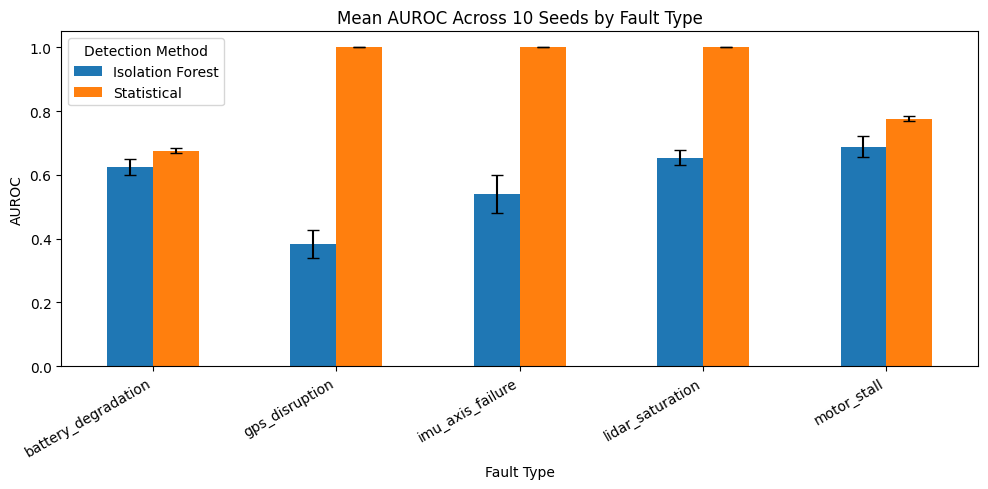

In [243]:
auroc_mean = (
    all_seed_results
    .groupby(
        ["Fault Type", "Method"]
    )["AUROC"]
    .mean()
    .unstack()
)

auroc_std = (
    all_seed_results
    .groupby(
        ["Fault Type", "Method"]
    )["AUROC"]
    .std()
    .unstack()
)

ax = auroc_mean.plot(
    kind="bar",
    yerr=auroc_std,
    capsize=4,
    figsize=(10, 5)
)

ax.set_title(
    "Mean AUROC Across 10 Seeds by Fault Type"
)

ax.set_xlabel("Fault Type")
ax.set_ylabel("AUROC")
ax.set_ylim(0, 1.05)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.legend(
    title="Detection Method"
)

plt.tight_layout()
plt.show()

**Figure Interpretation**

Statistical detection achieved higher mean AUROC across all five controlled fault types. The largest performance gaps occurred for GPS disruption and IMU axis failure, while Isolation Forest performed most strongly on LiDAR saturation and motor stall. Statistical AUROC also showed lower variability across the paired experiments, particularly for faults represented by explicit sensor-state rules.

## Key Findings and Operational Implications

The ten-seed paired evaluation showed that detection effectiveness depended strongly on the underlying fault mechanism.

1. **Statistical detection achieved the highest mean AUROC for all five controlled fault types.** Performance was strongest for GPS disruption, LiDAR saturation, and IMU axis failure, each achieving an AUROC of 1.000.

2. **Isolation Forest was most effective for LiDAR saturation and motor stall.** Their mean AUROC values were 0.766 and 0.730, respectively, indicating that the model was more successful when faults produced strong instantaneous numerical deviations.

3. **GPS disruption was the most difficult fault for Isolation Forest.** Its mean AUROC was 0.383, demonstrating that missing-coordinate failures were poorly represented by a model trained only on clean numerical telemetry.

4. **Motor stall and battery degradation demonstrated a precision-recall trade-off.** Isolation Forest achieved higher observation-level recall, while statistical detection provided higher AUROC, higher precision, and more stable performance across seeds.

Operationally, these findings support a hybrid monitoring strategy. Explicit sensor-state rules are appropriate for known failure signatures such as GPS loss, LiDAR saturation, and unresponsive IMU axes, while multivariate anomaly detection can provide complementary monitoring for less explicitly defined telemetry deviations.

## Limitations

Several limitations should be considered when interpreting the benchmark results.

First, the controlled faults were injected into synthetic telemetry using predefined failure signatures. Perfect statistical detection of GPS disruption, LiDAR saturation, and IMU axis failure therefore reflects the direct correspondence between the simulated faults and their diagnostic rules and may overestimate performance on real-world sensor failures.

Second, Isolation Forest was trained primarily on raw telemetry values. Faults characterized by temporal behavior, such as accelerated battery degradation or sustained loss of IMU variability, may not be fully represented by individual observations.

Third, the default Isolation Forest decision threshold produced a large number of anomaly predictions, resulting in very low precision. Operational deployment would require threshold calibration based on an acceptable false-alarm rate.

Finally, the benchmark evaluates controlled synthetic faults rather than confirmed failures from deployed robots. Future validation should therefore include real operational fault records and a broader range of fault severity and duration.